In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

In [12]:
df_h = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\analisis_detallado_hyades.csv")   
df_c = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\coma_sample.csv")
df_a = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_shell\gaia_parallax5_10_fidelity.csv")   
df_a = df_a[df_a["phot_bp_mean_mag"]<18].copy()

In [13]:
error_cols = ["parallax_error", "pmra_error", "pmdec_error"]


def get_log_errors(df, cols=error_cols):
    """
    Devuelve un DataFrame con log10 de los errores,
    usando solo valores positivos y finitos.
    """
    out = df[cols].copy()

    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    mask = np.ones(len(out), dtype=bool)

    for col in cols:
        mask &= np.isfinite(out[col].values)
        mask &= out[col].values > 0

    out = out.loc[mask].copy()

    for col in cols:
        out[f"log10_{col}"] = np.log10(out[col])

    return out

In [14]:
h_err = get_log_errors(df_h)
c_err = get_log_errors(df_c)
a_err = get_log_errors(df_a)

print("Hyades:", len(h_err))
print("Coma:", len(c_err))
print("Gaia referencia:", len(a_err))

Hyades: 455
Coma: 263
Gaia referencia: 212536


In [15]:
def bootstrap_1d_test(
    cluster_df,
    gaia_df,
    col,
    n_boot=5000,
    seed=42,
    statistic="ks",
):
    """
    Prueba empírica 1D.

    H0: la muestra del cúmulo proviene de la distribución empírica de Gaia.

    statistic:
        "ks"          -> estadístico D de Kolmogorov-Smirnov
        "wasserstein" -> distancia Wasserstein
    """

    rng = np.random.default_rng(seed)

    x_obs = cluster_df[f"log10_{col}"].dropna().values
    x_gaia = gaia_df[f"log10_{col}"].dropna().values

    n = len(x_obs)

    if statistic == "ks":
        t_obs = ks_2samp(x_obs, x_gaia).statistic

        def stat_fun(x):
            return ks_2samp(x, x_gaia).statistic

    elif statistic == "wasserstein":
        t_obs = wasserstein_distance(x_obs, x_gaia)

        def stat_fun(x):
            return wasserstein_distance(x, x_gaia)

    else:
        raise ValueError("statistic debe ser 'ks' o 'wasserstein'.")

    t_boot = np.empty(n_boot)

    for i in range(n_boot):
        x_boot = rng.choice(x_gaia, size=n, replace=True)
        t_boot[i] = stat_fun(x_boot)

    p_value = (np.sum(t_boot >= t_obs) + 1) / (n_boot + 1)

    result = {
        "variable": col,
        "n_cluster": n,
        "statistic": statistic,
        "T_obs": t_obs,
        "p_value": p_value,
        "T_boot_median": np.median(t_boot),
        "T_boot_95": np.quantile(t_boot, 0.95),
        "T_boot_99": np.quantile(t_boot, 0.99),
    }

    return result, t_boot

In [16]:
def run_all_1d_tests(cluster_df, gaia_df, cluster_name, n_boot=5000):
    rows = []

    for col in error_cols:
        for stat in ["ks", "wasserstein"]:
            res, _ = bootstrap_1d_test(
                cluster_df=cluster_df,
                gaia_df=gaia_df,
                col=col,
                n_boot=n_boot,
                seed=42,
                statistic=stat,
            )

            res["cluster"] = cluster_name
            rows.append(res)

    return pd.DataFrame(rows)


results_h = run_all_1d_tests(h_err, a_err, "Hyades", n_boot=100)
results_c = run_all_1d_tests(c_err, a_err, "Coma", n_boot=100)

results = pd.concat([results_h, results_c], ignore_index=True)

results

,variable,n_cluster,statistic,T_obs,p_value,T_boot_median,T_boot_95,T_boot_99,cluster
0,parallax_error,455,ks,0.234784,0.009901,0.037988,0.063872,0.073777,Hyades
1,parallax_error,455,wasserstein,0.225694,0.009901,0.019229,0.033273,0.046895,Hyades
2,pmra_error,455,ks,0.297041,0.009901,0.040009,0.059927,0.070306,Hyades
3,pmra_error,455,wasserstein,0.302436,0.009901,0.020547,0.036456,0.046876,Hyades
4,pmdec_error,455,ks,0.203844,0.009901,0.039325,0.057299,0.063477,Hyades
5,pmdec_error,455,wasserstein,0.178497,0.009901,0.018684,0.033739,0.045848,Hyades
6,parallax_error,263,ks,0.290563,0.009901,0.050101,0.086126,0.110453,Coma
7,parallax_error,263,wasserstein,0.255420,0.009901,0.026809,0.048316,0.059114,Coma
8,pmra_error,263,ks,0.277550,0.009901,0.049518,0.084785,0.095276,Coma
9,pmra_error,263,wasserstein,0.271578,0.009901,0.027432,0.044439,0.064059,Coma


In [20]:
alpha = 0.05

results["compatible_con_gaia"] = results["p_value"] < alpha

results[
    [
        "cluster",
        "variable",
        "statistic",
        "n_cluster",
        "T_obs",
        "T_boot_95",
        "T_boot_99",
        "p_value",
        "compatible_con_gaia",
    ]
]

,cluster,variable,statistic,n_cluster,T_obs,T_boot_95,T_boot_99,p_value,compatible_con_gaia
0,Hyades,parallax_error,ks,455,0.234784,0.063872,0.073777,0.009901,True
1,Hyades,parallax_error,wasserstein,455,0.225694,0.033273,0.046895,0.009901,True
2,Hyades,pmra_error,ks,455,0.297041,0.059927,0.070306,0.009901,True
3,Hyades,pmra_error,wasserstein,455,0.302436,0.036456,0.046876,0.009901,True
4,Hyades,pmdec_error,ks,455,0.203844,0.057299,0.063477,0.009901,True
5,Hyades,pmdec_error,wasserstein,455,0.178497,0.033739,0.045848,0.009901,True
6,Coma,parallax_error,ks,263,0.290563,0.086126,0.110453,0.009901,True
7,Coma,parallax_error,wasserstein,263,0.255420,0.048316,0.059114,0.009901,True
8,Coma,pmra_error,ks,263,0.277550,0.084785,0.095276,0.009901,True
9,Coma,pmra_error,wasserstein,263,0.271578,0.044439,0.064059,0.009901,True


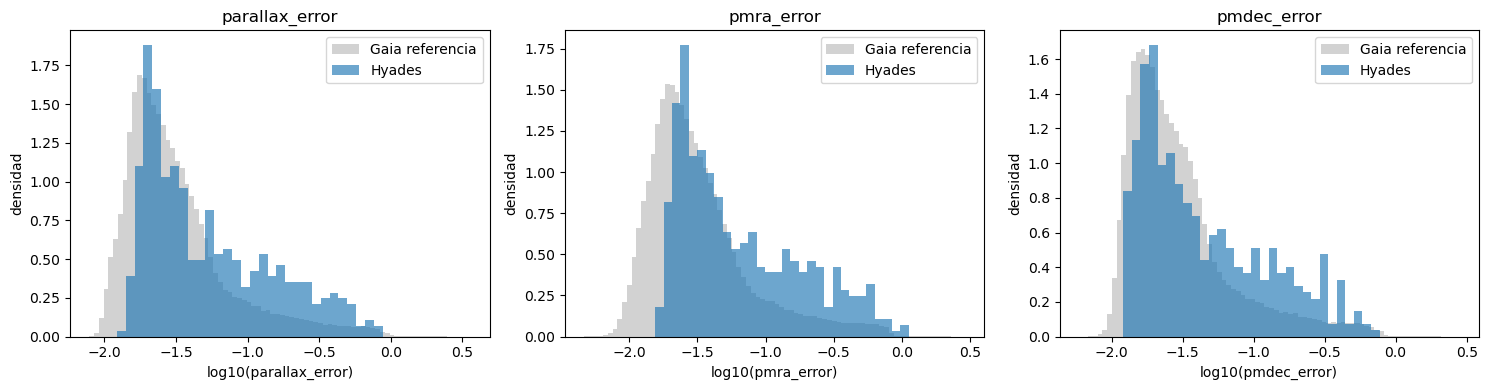

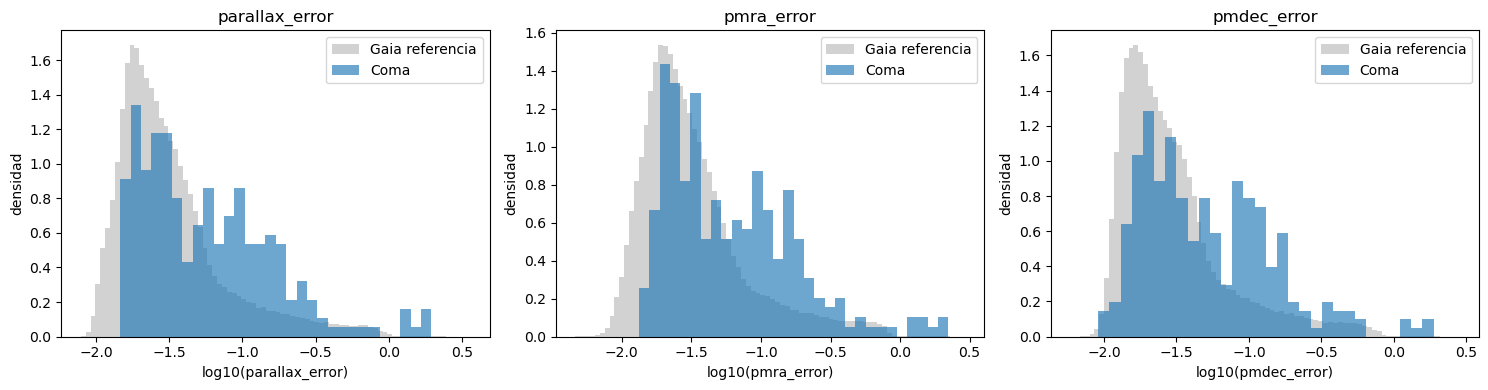

In [18]:

def plot_error_distributions(cluster_df, gaia_df, cluster_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, col in zip(axes, error_cols):
        x_gaia = gaia_df[f"log10_{col}"].dropna().values
        x_cl = cluster_df[f"log10_{col}"].dropna().values

        ax.hist(
            x_gaia,
            bins=80,
            density=True,
            alpha=0.35,
            label="Gaia referencia",
            color="gray",
        )

        ax.hist(
            x_cl,
            bins=30,
            density=True,
            alpha=0.65,
            label=cluster_name,
        )

        ax.set_xlabel(f"log10({col})")
        ax.set_ylabel("densidad")
        ax.set_title(col)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_error_distributions(h_err, a_err, "Hyades")
plot_error_distributions(c_err, a_err, "Coma")

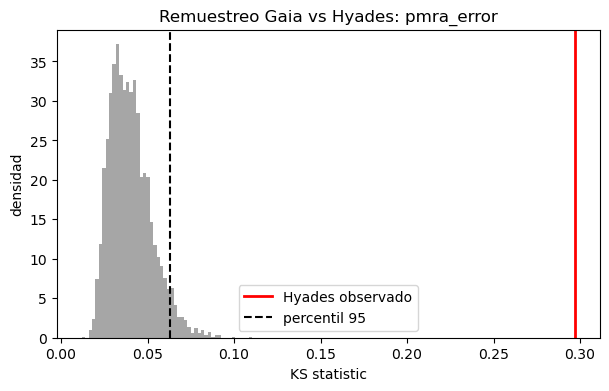

{'variable': 'pmra_error',
 'n_cluster': 455,
 'statistic': 'ks',
 'T_obs': 0.2970411942106149,
 'p_value': 0.0001999600079984003,
 'T_boot_median': 0.03858363283872375,
 'T_boot_95': 0.0629712758164409,
 'T_boot_99': 0.07571499178729954}

In [19]:
res_h_pmra, boot_h_pmra = bootstrap_1d_test(
    cluster_df=h_err,
    gaia_df=a_err,
    col="pmra_error",
    n_boot=5000,
    seed=42,
    statistic="ks",
)

plt.figure(figsize=(7, 4))
plt.hist(boot_h_pmra, bins=50, density=True, alpha=0.7, color="gray")
plt.axvline(res_h_pmra["T_obs"], color="red", lw=2, label="Hyades observado")
plt.axvline(res_h_pmra["T_boot_95"], color="black", ls="--", label="percentil 95")
plt.xlabel("KS statistic")
plt.ylabel("densidad")
plt.title("Remuestreo Gaia vs Hyades: pmra_error")
plt.legend()
plt.show()

res_h_pmra